In [1]:
import sys
sys.path.append('../')

import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
from sympy import symbols
import utils_2Q_gate_zp as ut
# import sigmaX_fidelity_optimize as zpX
from brokenaxes import brokenaxes
import qutip as qt
import scqubits as scq
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import plotly.graph_objects as go
import plotly.io as pio
import scipy as sp
from scipy.ndimage import gaussian_filter
from joblib import Parallel, delayed
from IPython.display import display, Math

In [2]:
truncation, truc1 = 1000, 300
folder = '../../data/3ncut_one_zeropi/'
eval0 = 2*np.pi* scq.read(folder + f'zeropi_0_specdata_truc={truncation}_3ncut.h5').energy_table
n_theta0 = 2*np.pi* scq.read(folder + f'zeropi_0_n_theta_truc={truncation}_3ncut.h5').matrixelem_table
n_phi0 = 2*np.pi* scq.read(folder + f'zeropi_0_n_phi_truc={truncation}_3ncut.h5').matrixelem_table
eval1 = 2*np.pi* scq.read(folder + f'zeropi_1_specdata_truc={truncation}_3ncut.h5').energy_table
n_theta1 = 2*np.pi* scq.read(folder + f'zeropi_1_n_theta_truc={truncation}_3ncut.h5').matrixelem_table
n_phi1 = 2*np.pi* scq.read(folder + f'zeropi_1_n_phi_truc={truncation}_3ncut.h5').matrixelem_table
eval0 = eval0 - eval0[0]
eval1 = eval1 - eval1[0]

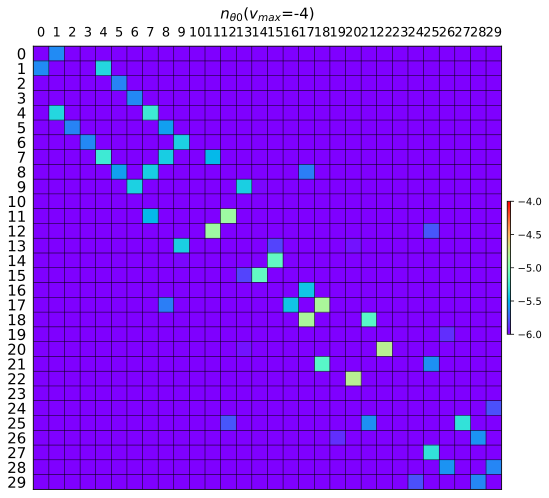

In [3]:
vmax = -4 #1e-8
vmin = -6 #1e-8
truc2 = 30
fig, ax = plt.subplots(figsize=(10,8))
font_size = 15
plt.imshow(np.log10(1.39e-6 * np.abs(n_theta0[:truc2,:truc2]/(2*np.pi))**2 ),
           vmax=vmax, vmin=vmin, aspect="auto",cmap='rainbow')
plt.title(r'$n_{\theta 0}$($v_{max}$='+f'{vmax})' , pad=8, fontsize=font_size)
ax.set_xticks(np.arange(0, truc2), np.arange(0, truc2), fontsize=13)
ax.set_yticks(np.arange(0, truc2), np.arange(0, truc2), fontsize=15)
ax.xaxis.tick_top()
ax.set_xticks(np.arange(-.5, truc2, 1), minor=True)
ax.set_yticks(np.arange(-.5, truc2, 1), minor=True)
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
ax.tick_params(which='both', left=False, top=False)
plt.colorbar(shrink=0.3, aspect=40, pad=0.01)
# plt.savefig('image/n_theta.png',dpi=150, bbox_inches='tight')

#### Matrix element table

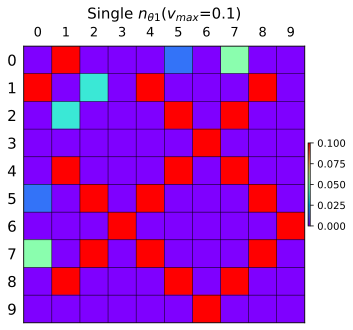

In [6]:
vmax = 0.1
truc2 = 10
fig, ax = plt.subplots(figsize=(6,5))
font_size = 15
plt.imshow(np.abs(n_theta0[:truc2,:truc2]/(2*np.pi)), vmax=vmax, aspect="auto",cmap='rainbow')
plt.title(r'Single $n_{\theta 1}$($v_{max}$='+f'{vmax})' , pad=8, fontsize=font_size)
ax.set_xticks(np.arange(0, truc2), np.arange(0, truc2), fontsize=13)
ax.set_yticks(np.arange(0, truc2), np.arange(0, truc2), fontsize=15)
ax.xaxis.tick_top()
ax.set_xticks(np.arange(-.5, truc2, 1), minor=True)
ax.set_yticks(np.arange(-.5, truc2, 1), minor=True)
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
ax.tick_params(which='both', left=False, top=False)
plt.colorbar(shrink=0.3, aspect=40, pad=0.01)
# plt.savefig('image/n_theta.png',dpi=150, bbox_inches='tight')

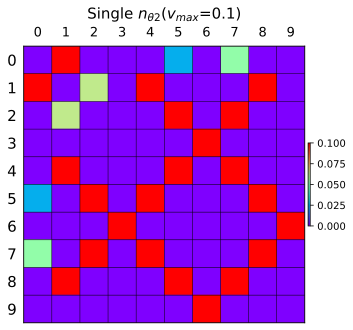

In [7]:
vmax = 0.1
truc2 = 10
fig, ax = plt.subplots(figsize=(6,5))
plt.imshow(np.abs(n_theta1[:truc2,:truc2]/(2*np.pi)), vmax=vmax, aspect="auto",cmap='rainbow')
plt.title(r'Single $n_{\theta 2}$($v_{max}$='+f'{vmax})' , pad=8, fontsize=15)
ax.set_xticks(np.arange(0, truc2), np.arange(0, truc2), fontsize=13)
ax.set_yticks(np.arange(0, truc2), np.arange(0, truc2), fontsize=15)
ax.xaxis.tick_top()
ax.set_xticks(np.arange(-.5, truc2, 1), minor=True)
ax.set_yticks(np.arange(-.5, truc2, 1), minor=True)
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
ax.tick_params(which='both', left=False, top=False)
plt.colorbar(shrink=0.3, aspect=40, pad=0.01)
# plt.savefig('image/n_theta.png',dpi=150, bbox_inches='tight')

In [9]:
n_theta1

array([[ 2.01060008e-14, -7.93591925e+00,  4.36124854e-14, ...,
         1.40162436e-17, -3.51465562e-17,  4.07920539e-17],
       [-7.93591925e+00,  1.21373295e-13,  3.94458467e-01, ...,
        -3.14585272e-16, -8.41721376e-17, -2.22948897e-16],
       [ 4.36097371e-14,  3.94458467e-01,  8.25960738e-17, ...,
        -5.57376842e-17, -9.12462517e-17, -1.79097473e-17],
       ...,
       [ 1.22244605e-17, -3.25413348e-16, -5.61510317e-17, ...,
        -5.28721806e-07, -8.53463168e+00, -1.54306072e-06],
       [-3.80214514e-17, -8.32255146e-17, -9.12301902e-17, ...,
        -8.53463168e+00, -3.73717643e-05,  1.00853609e+02],
       [ 4.06810961e-17, -2.23580017e-16, -1.81132445e-17, ...,
        -1.54306072e-06,  1.00853609e+02,  3.73717571e-05]])

In [25]:
qt.Qobj(np.abs(n_theta0[:truc2,:truc2])[[2,0]]).tidyup()/(2*np.pi)

Quantum object: dims = [[2], [10]], shape = (2, 10), type = oper, isherm = False
Qobj data =
[[0.         0.0365515  0.         0.         0.         1.26186733
  0.         0.1908349  0.         0.        ]
 [0.         1.30441556 0.         0.         0.         0.01492543
  0.         0.0522436  0.         0.        ]]

In [ ]:
qt.Qobj(np.abs(n_theta1[:truc2,:truc2])[[2,0]]).tidyup()/(2*np.pi)

Quantum object: dims = [[2], [10]], shape = (2, 10), type = oper, isherm = False
Qobj data =
[[0.         0.06278001 0.         0.         0.         1.18428544
  0.         0.30353285 0.         0.        ]
 [0.         1.26304078 0.         0.         0.         0.02382819
  0.         0.05387578 0.         0.        ]]

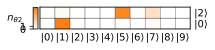

In [16]:
from matplotlib.colors import LinearSegmentedColormap
custom_cmap2 = LinearSegmentedColormap.from_list("orange_white", ["#ffffff", "#ff7f0e"])# "#ff7f0e" Orange
# np.savetxt('data/n_theta2_bare.txt', n_theta2.view(float), delimiter=','),  
mat = np.abs(np.array([n_theta1[0, :10], n_theta1[2, :10]]))
vmax = np.max(mat)
x_size, y_size = 2.7, 0.4
fig, ax = plt.subplots(figsize=(x_size, y_size))
mappable = plt.pcolor(mat, edgecolors="k", cmap=custom_cmap2, vmax=vmax)
ax.set_xticks(np.arange(0.5, mat.shape[1], 1), ['$|$'+str(i)+'$\\rangle$' for i in np.arange(0, mat.shape[1])]  )
ax.set_yticks(np.arange(0.5, mat.shape[0], 1), [r"$|0\rangle$", r"$|2\rangle$"])
ax.yaxis.tick_right()
ax.yaxis.set_ticks_position('right')
ax.tick_params(axis="both", pad=4, length=0)  # Adjust padding for x-axis ticks

cbar_ax = fig.add_axes([0.09, 0.11, 0.025, 0.75]) # [left, bottom, width, height] in figure fraction (0 to 1)
cbar = fig.colorbar(mappable, aspect=5, cax=cbar_ax, pad=0.02, ticks=[0, 1])  # Shrinks the colorbar to 80% of its default size
cbar.set_ticklabels(["0", "1"])  # Custom tick labels
cbar.set_label(r"$n_{\theta 2}$", rotation=0, labelpad=5)
cbar.ax.yaxis.set_label_position('left')
cbar.ax.yaxis.set_ticks_position('left')       # Put ticks on the left
cbar.ax.yaxis.label.set_position((1., 0.3))  # y=0.5 is center; >0.5 moves up, <0.5 moves down

# cbar.ax.tick_params(    size=1, direction="in", length=tick_length, width=tick_width, labelsize=SMALL_SIZE)  # Font size for colorbar ticks
# plt.savefig("pdf_before_inkscape/cz_ntheta2.pdf", dpi=300, bbox_inches="tight", pad_inches = 0.02,)

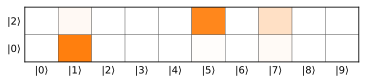

In [23]:
# np.savetxt('data/n_theta2_bare.txt', n_theta2.view(float), delimiter=',')
mat = np.abs(np.array([n_theta1[0, :10], n_theta1[2, :10]]))
vmax = np.max(mat)
x_size, y_size = 6.0, 1
fig, ax = plt.subplots(figsize=(x_size, y_size))
mappable = plt.pcolor(mat, edgecolors="k", cmap=custom_cmap2, vmax=vmax)
ax.set_xticks(np.arange(0.5, mat.shape[1], 1), ['$|$'+str(i)+'$\\rangle$' for i in np.arange(0, mat.shape[1])]  )
ax.set_yticks(np.arange(0.5, mat.shape[0], 1), [r"$|0\rangle$", r"$|2\rangle$"])
# ax.yaxis.tick_right()
# ax.yaxis.set_ticks_position('right')
ax.tick_params(axis="both", pad=4, length=0)  # Adjust padding for x-axis ticks

# cbar_ax = fig.add_axes([0.09, 0.11, 0.025, 0.75]) # [left, bottom, width, height] in figure fraction (0 to 1)
# cbar = fig.colorbar(mappable, aspect=5, pad=0.02, ticks=[0, 1])  # Shrinks the colorbar to 80% of its default size
# cbar.set_ticklabels(["0", "1"])  # Custom tick labels
# cbar.set_label(r"$n_{\theta 2}$", rotation=0, labelpad=5)
# # cbar.ax.yaxis.set_label_position('left')
# # cbar.ax.yaxis.set_ticks_position('left')       # Put ticks on the left
# cbar.ax.yaxis.label.set_position((1., 0.55))  # y=0.5 is center; >0.5 moves up, <0.5 moves down

# cbar.ax.tick_params(    size=1, direction="in", length=1, width=0.4, labelsize=5)  # Font size for colorbar ticks


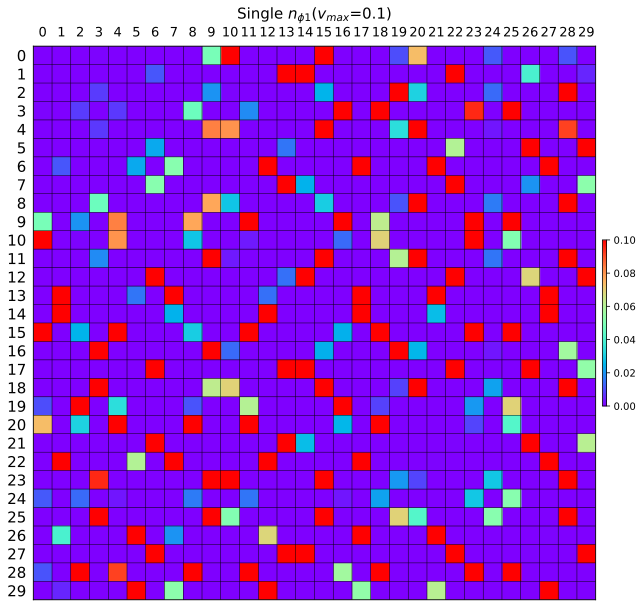

In [7]:
vmax = 0.1
truc2 = 30
fig, ax = plt.subplots(figsize=(12,10))
plt.imshow(np.abs(n_phi0[:truc2,:truc2]/(2*np.pi)), vmax=vmax, aspect="auto",cmap='rainbow')
plt.title(r'Single $n_{\phi 1}$($v_{max}$='+f'{vmax})' , pad=8, fontsize=15)
ax.set_xticks(np.arange(0, truc2), np.arange(0, truc2), fontsize=13)
ax.set_yticks(np.arange(0, truc2), np.arange(0, truc2), fontsize=15)
ax.xaxis.tick_top()
ax.set_xticks(np.arange(-.5, truc2, 1), minor=True)
ax.set_yticks(np.arange(-.5, truc2, 1), minor=True)
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
ax.tick_params(which='both', left=False, top=False)
plt.colorbar(shrink=0.3, aspect=40, pad=0.01)
# plt.savefig('image/n_theta.png',dpi=150, bbox_inches='tight')

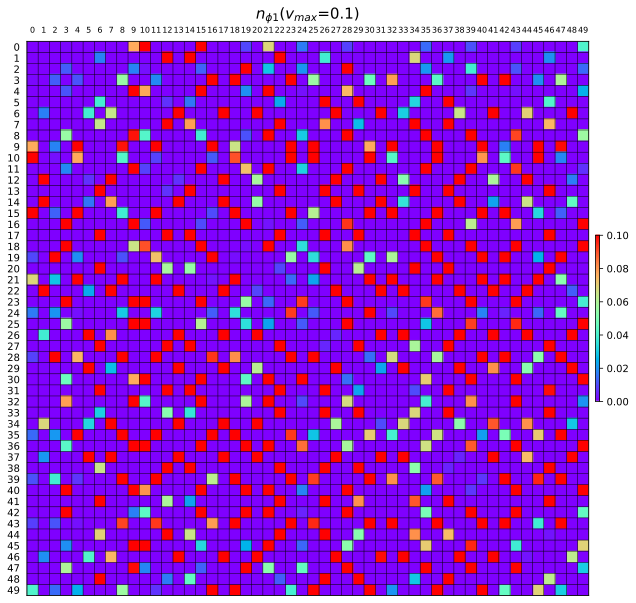

In [8]:
vmax = 0.1
truc2 = 50
fig, ax = plt.subplots(figsize=(12,10))
plt.imshow(np.abs(n_phi1[:truc2,:truc2]/(2*np.pi)), vmax=vmax, aspect="auto",cmap='rainbow')
plt.title(r'$n_{\phi 1}$($v_{max}$='+f'{vmax})' , pad=8, fontsize=15)
ax.set_xticks(np.arange(0, truc2), np.arange(0, truc2), fontsize=8)
ax.set_yticks(np.arange(0, truc2), np.arange(0, truc2), fontsize=10)
ax.xaxis.tick_top()
ax.set_xticks(np.arange(-.5, truc2, 1), minor=True)
ax.set_yticks(np.arange(-.5, truc2, 1), minor=True)
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
ax.tick_params(which='both', left=False, top=False)
plt.colorbar(shrink=0.3, aspect=40, pad=0.01)
# plt.savefig('image/n_theta.png',dpi=150, bbox_inches='tight')

In [12]:
hspace = np.arange(50).tolist()
ut.print_trans_freq(0, 7, eval0, hspace, n_Theta=n_theta0)
ut.print_trans_freq(2, 7, eval0, hspace, n_Theta=n_theta0)
ut.print_trans_freq(7, 25, eval0, hspace, n_Theta=n_theta0)
ut.print_trans_freq(0, 1, eval0, hspace, n_Theta=n_theta0)
ut.print_trans_freq(2, 5, eval0, hspace, n_Theta=n_theta0)
ut.print_trans_freq(1, 4, eval0, hspace, n_Theta=n_theta0)
ut.print_trans_freq(7, 11, eval0, hspace, n_Theta=n_theta0)

ut.print_trans_freq(0, 9, eval0, hspace, n_Phi=n_phi0)
ut.print_trans_freq(2, 9, eval0, hspace, n_Phi=n_phi0)
ut.print_trans_freq(0, 10, eval0, hspace, n_Phi=n_phi0)
ut.print_trans_freq(9, 33, eval0, hspace, n_Phi=n_phi0)
ut.print_trans_freq(2, 19, eval0, hspace, n_Phi=n_phi0)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### Charge matrix element

In [13]:
def get_w_trans(truncation, evals, n_op, state_pop):
    thresh = 1e-4
    hspace = [0, 2]
    for s in hspace:
        for i in range(truncation):
            if np.abs(n_op[s, i]/(2*np.pi)) > thresh and i not in hspace:
                hspace.append(i)
    hspace.sort()

    n_op = n_op[np.ix_(hspace, hspace)]
    w_trans = []
    trans_int = []
    n_trans = []
    for i, state_i in enumerate(hspace):
        if state_i in state_pop:
            for j, state_j in enumerate(hspace):
                if i < j and np.abs(n_op[i, j]/(2*np.pi)) > thresh:
                    w_trans.append(np.round( np.abs(evals[state_i] - evals[state_j]), 8))
                    trans_int.append((state_i, state_j))
                    n_trans.append( np.round( np.abs(n_op[i, j]/(2*np.pi)) , 3))
    sort_idx = np.argsort(w_trans)
    w_trans = np.sort(np.round(w_trans, 3))
    n_trans = [np.round(n_trans[i],3) for i in sort_idx]
    trans_int = [trans_int[i] for i in sort_idx]
    return w_trans, n_trans, trans_int



Text(0.5, 0, 'Frequency (2$\\pi\\cdot$GHz)')

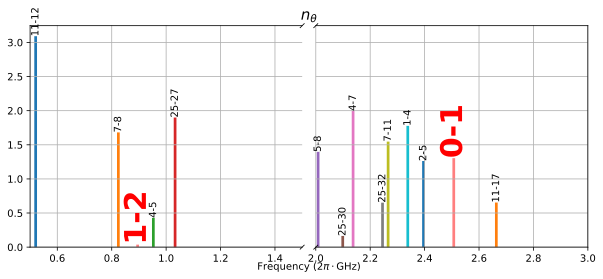

: 

In [ ]:
state_phi = [0, 2, 9, 10, 19, 33, 37, 47] # phi
state_theta = [0, 1, 2, 4, 5, 7, 8, 11, 25] #+ [ 12, 16, 17, 18, 21, 23, 25, ] # theta
w_trans, n_trans, trans_int = get_w_trans(truc1, eval0, n_theta0, state_theta)
width = 0.8
y_shift = 0.0
state_overlap = ['47-91', '9-31']
x_shift = [-0.3,-0.3]
xlims = ((0.5, 1.5), (2, 3)) # 1 state
# xlims = ((3, 4), (6.5, 7.5)) # 7 state
# xlims = ((27.3, 30.8), (49.1, 53.9))
fig = plt.figure(figsize=(10, 4))
bax = brokenaxes(xlims=xlims, wspace=0.05, d=0.004, despine=False, hspace=0.05)

for i in range(len(w_trans)):
    for xlim in xlims:
        if xlim[0] < w_trans[i]/(2*np.pi) < xlim[1]:
            txt_label = str(trans_int[i][0]) + '-' + str(trans_int[i][1])
            if trans_int[i] in [(0,1), (1,2)]:
                bax.bar(w_trans[i]/(2*np.pi), n_trans[i], width=0.01, color='red', alpha=0.5)
                bax.text(w_trans[i]/(2*np.pi), n_trans[i] +y_shift, txt_label, ha="center",
                         va="bottom", rotation=90, fontsize=30, fontweight='bold', color='red', alpha=1)
            # elif trans_int[i] in state_overlap:
                # bax.bar(w_trans[i], trans_mat[i], width=0.05)
                # bax.text(w_trans[i]+0.07, trans_mat[i] +y_shift, txt_label, ha="center", va="bottom", rotation=90, fontsize=10)
            else:
                bax.bar(w_trans[i]/(2*np.pi), n_trans[i], width=0.01, alpha=1)
                bax.text(w_trans[i]/(2*np.pi), n_trans[i] +y_shift, txt_label, ha="center", va="bottom", rotation=90, fontsize=10)
# bax.set_ylim(0, 0.4)
bax.grid()
bax.set_title(r'$n_\theta$', fontsize=15)
# bax.set_title(r'$n_\phi:\psi_0=$'+f'{state_good}', fontsize=15)
bax.set_xlabel(r'Frequency (2$\pi\cdot$GHz)')
# plt.grid()
# plt.xticks(np.arange(x_min, x_max, 2))  # Set custom x-axis ticks

In [15]:
len(trans_int)
# [print(i) if 47 in i else None for i in trans_int]
for i in trans_int:
    if 47 in i:
        # print(i)
        ut.print_trans_freq(i[0], i[1], eval0, n_Phi=n_phi0)

TypeError: print_trans_freq() missing 1 required positional argument: 'hspace'

Text(0.5, 0, 'Frequency (2$\\pi\\cdot$GHz)')

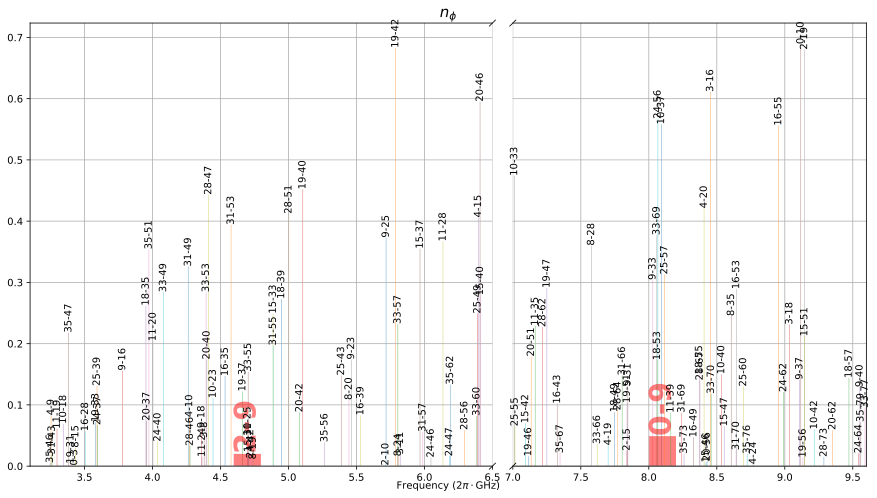

In [ ]:
# state_phi = [0, 2, 9, 10, 19, 33, 37, 47] # phi
state_phi = [0, 2, 3, 4, 8, 9, 10, 11, 15, 16 ,
18, 19, 20, 24, 25, 28, 31, 33, 35 ]
w_trans, n_trans, trans_int = get_w_trans(truc1, eval0, n_phi0, state_phi)
width = 0.8
y_shift = 0.0
state_overlap = ['47-91', '9-31']
x_shift = [-0.3,-0.3]
# xlims = ((0.5, 1.5), (2, 3)) # 1 state
xlims = ((3.1, 6.5), (7., 9.6)) # 7 state
# xlims = ((27.3, 30.8), (49.1, 53.9))
fig = plt.figure(figsize=(15, 8))
bax = brokenaxes(xlims=xlims, wspace=0.05, d=0.004, despine=False, hspace=0.05)

for i in range(len(w_trans)):
    for xlim in xlims:
        if xlim[0] < w_trans[i]/(2*np.pi) < xlim[1]:
            txt_label = str(trans_int[i][0]) + '-' + str(trans_int[i][1])
            if trans_int[i] in [(0,9), (2,9)]:
                bax.bar(w_trans[i]/(2*np.pi), n_trans[i], width=0.2, color='red', alpha=0.5)
                bax.text(w_trans[i]/(2*np.pi), n_trans[i] +y_shift, txt_label, ha="center",
                         va="bottom", rotation=90, fontsize=30, fontweight='bold', color='red', alpha=0.5)
            else:
                bax.bar(w_trans[i]/(2*np.pi), n_trans[i], width=0.005, alpha=0.5)
                bax.text(w_trans[i]/(2*np.pi), n_trans[i] +y_shift, txt_label, ha="center", va="bottom", rotation=90, fontsize=10)
# bax.set_ylim(0, 0.4)
bax.grid()
bax.set_title(r'$n_\phi$', fontsize=15)
# bax.set_title(r'$n_\phi:\psi_0=$'+f'{state_good}', fontsize=15)
bax.set_xlabel(r'Frequency (2$\pi\cdot$GHz)')
# plt.grid()
# plt.xticks(np.arange(x_min, x_max, 2))  # Set custom x-axis ticks

In [ ]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

Text(0.5, 1.0, '$n_\\theta$')

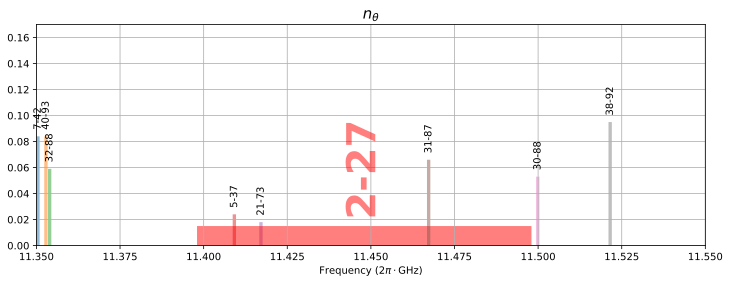

In [ ]:
fig, ax = plt.subplots(figsize=(12,4))
y_shift = 0.005
state_overlap = ['0-10']
x_shift = [-0.3]
x_min, x_max =11.35, 11.55
for i,_ in enumerate(w_trans):
    if x_min < w_trans[i]/(2*np.pi) < x_max:# and trans_mat[i] < 2:
        if trans[i] in ['0-27', '2-27']:
            plt.bar(w_trans[i]/(2*np.pi), n_trans[i], width=0.1, color='red', alpha=0.5)
            plt.text(w_trans[i]/(2*np.pi), n_trans[i] +y_shift, trans[i],
                     ha="center", va="bottom", rotation=90, fontsize=40, fontweight='bold', color='red', alpha=0.5)
        # elif trans[i] in state_overlap:
        #     plt.bar(w_trans[i], trans_mat[i], width=0.02)
            # plt.text(w_trans[i]-0.3, trans_mat[i] +y_shift, trans[i], ha="center", va="bottom", rotation=90, fontsize=5)
        else:
            plt.bar(w_trans[i]/(2*np.pi), n_trans[i], width=0.001, alpha=0.5)
            plt.text(w_trans[i]/(2*np.pi), n_trans[i] +y_shift, trans[i], ha="center", va="bottom", rotation=90, fontsize=10)

plt.ylim(0,0.17)
plt.xlim(x_min,x_max)
plt.xlabel(r'Frequency (2$\pi\cdot$GHz)')
plt.grid()
# plt.xticks(np.arange(x_min, x_max, 2))  # Set custom x-axis ticks
# plt.ylabel('Max population during X gate')
ax.set_title(r'$n_\theta$', fontsize=15)
# plt.title(r'$n_\phi:\psi_0=$'+f'{state_good}', fontsize=15)

#### Find hilbert space - indirectly connected states

In [ ]:
truc1 = 100
drive_phi, drive_theta = False, True

In [ ]:
EL        = 0.377 # GHz
EJ        = 6.013 # Soft Zero Pi (Gyenis)
EC_phi    = 1.142
EC_theta  = 0.092
E_CJ = 2 * EC_phi
E_C = 2./(1./EC_theta -1./EC_phi)

phi_grid = scq.Grid1d(-6*np.pi, 6*np.pi, 300)
zero_pi = scq.ZeroPi(grid=phi_grid, EJ=EJ, EL=EL, ECJ=E_CJ, EC = E_C, dEJ=0.,
                        ng=0., flux=0., ncut=90, truncated_dim=truc1)
n_theta = zero_pi.matrixelement_table(operator='n_theta_operator', evals_count=truc1)
n_phi = zero_pi.matrixelement_table(operator='i_d_dphi_operator', evals_count=truc1)
n_phi0 = 2*np.pi * qt.Qobj(n_phi)
n_theta0 = 2*np.pi * qt.Qobj(n_theta)

eval0 = 2*np.pi * zero_pi.eigenvals(evals_count=truc1)
H0 = qt.Qobj(np.diag(eval0))

if drive_phi:
    w_trans_1 = eval0[9] - eval0[0]
    w_trans_2 = eval0[9] - eval0[2]
    drive_term = n_phi0
if drive_theta:
    w_trans_1 = eval0[7] - eval0[0]
    w_trans_2 = eval0[7] - eval0[2]
    drive_term = n_theta0
if drive_phi and drive_theta:
    w_trans_1 = eval0[9] - eval0[0]
    w_trans_2 = eval0[9] - eval0[2]
    drive_term = 0.976*n_phi0+ 0.024*n_theta0

In [ ]:
# drive_phi, drive_theta = False, True
drive_phi, drive_theta = True, False
drive_term = n_theta0 if drive_theta else n_phi0

thresh = 1e-4
hspace_indirect = [0, 2]
for s in hspace_indirect:
    for i in range(truc1):
        if np.abs(drive_term[s, i]/(2*np.pi)) > thresh and i not in hspace_indirect:
            hspace_indirect.append(i)
hspace_indirect.sort()

hilbert_space = hspace_indirect
truc2 = len(hilbert_space)
print('threshold=', thresh)
print('num of truncation =', truc2)
print('hilbert_space :')
dim = 10
data = hilbert_space
for i in range(0, len(data), dim):
    print(', '.join(map(str, data[i:i+dim] )), ',')

threshold= 0.0001
num of truncation = 160
hilbert_space :
0, 2, 3, 4, 8, 9, 10, 11, 15, 16 ,
18, 19, 20, 23, 24, 25, 28, 31, 33, 35 ,
37, 39, 40, 42, 43, 46, 47, 49, 51, 53 ,
55, 56, 57, 60, 62, 64, 66, 67, 69, 70 ,
73, 76, 77, 79, 81, 83, 85, 86, 88, 91 ,
92, 95, 96, 98, 100, 101, 102, 104, 106, 108 ,
110, 112, 113, 116, 118, 120, 121, 123, 126, 128 ,
130, 132, 133, 136, 137, 139, 141, 143, 145, 146 ,
148, 151, 153, 154, 156, 158, 159, 162, 164, 166 ,
167, 169, 170, 173, 174, 176, 179, 181, 183, 185 ,
186, 188, 190, 192, 194, 196, 198, 200, 202, 205 ,
206, 208, 209, 212, 213, 216, 218, 220, 222, 223 ,
226, 227, 229, 230, 232, 234, 237, 239, 241, 242 ,
245, 246, 248, 250, 252, 253, 255, 257, 259, 262 ,
264, 265, 267, 269, 271, 273, 275, 277, 279, 281 ,
282, 283, 286, 288, 290, 291, 293, 294, 297, 299 ,


In [ ]:
hilbert_space = hspace_indirect
H0_truc = ut.truncate_2(H0, hilbert_space)
drive_truc = ut.truncate_2(drive_term, hilbert_space)
drive_truc = drive_truc.tidyup(atol=1e-5)

In [ ]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

#### Find hilbert space - directly connected states

In [ ]:
thresh = 1e-3
hspace_logi = [0, 2]
hspace_direct = [0, 2]
for s in hspace_logi:
    for i in range(truc1):
        if np.abs(drive_term[s, i]/(2*np.pi)) > thresh and i not in hspace_direct:
            hspace_direct.append(i)
hspace_direct.sort()

hilbert_space = hspace_direct
truc2 = len(hilbert_space)
print('threshold=', thresh)
print('num of truncation =', truc2)
print('hilbert_space :')
dim = 10
data = hilbert_space
for i in range(0, len(data), dim):
    print(', '.join(map(str, data[i:i+dim] )), ',')

threshold= 0.001
num of truncation = 49
hilbert_space :
0, 2, 3, 9, 10, 15, 19, 20, 24, 28 ,
35, 39, 43, 49, 53, 55, 57, 60, 66, 69 ,
70, 77, 81, 86, 91, 95, 100, 101, 104, 108 ,
110, 113, 116, 126, 130, 136, 139, 141, 145, 146 ,
148, 153, 159, 164, 173, 194, 205, 209, 253 ,


In [ ]:
thresh = 1e-2
hspace_logi = [0, 2]
hspace_direct = [0, 2]
for s in hspace_logi:
    for i in range(truc1):
        if np.abs(drive_term[s, i]/(2*np.pi)) > thresh and i not in hspace_direct:
            hspace_direct.append(i)
hspace_direct.sort()

hilbert_space = hspace_direct
truc2 = len(hilbert_space)
print('threshold=', thresh)
print('num of truncation =', truc2)
print('hilbert_space :')
dim = 10
data = hilbert_space
for i in range(0, len(data), dim):
    print(', '.join(map(str, data[i:i+dim] )), ',')

threshold= 0.01
num of truncation = 25
hilbert_space :
0, 2, 9, 10, 15, 19, 20, 24, 28, 35 ,
39, 43, 53, 55, 57, 66, 69, 81, 91, 95 ,
100, 101, 104, 108, 116 ,


In [ ]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

In [ ]:
hilbert_space = hspace_indirect
H0_truc = ut.truncate_2(H0, hilbert_space)
drive_truc = ut.truncate_2(drive_term, hilbert_space)
drive_truc = drive_truc.tidyup(atol=1e-5)
# np.savetxt("n_theta_157.txt", drive_truc.full(), delimiter=",", fmt="%.4f")  # Save as CSV
# np.savetxt("H0_theta_157.txt", H0_truc.full(), delimiter=",", fmt="%.4f")  # Save as CSV

In [ ]:
# H0_truc_direct = np.loadtxt("H0_truc_direct.txt", dtype=complex, delimiter=",")
# n_theta_truc_direct = np.loadtxt("n_theta_truc_direct.txt", dtype=complex, delimiter=",")
# print('H0_truc_direct=', H0_truc_direct)
# print('n_theta_truc_direct=', n_theta_truc_direct)

In [ ]:
state_w_close_trans = []

w_thresh = 0.1
for i in hspace_indirect:
    for j in hspace_indirect:
        if j > i:
            n_ij = np.abs(drive_term[i, j])
            # Assume very close to resonance driving -- not actually true
            delta1 = abs(w_trans_1 - (eval0[j] - eval0[i]))
            delta2 = abs(w_trans_2 - (eval0[j] - eval0[i]))
            if delta1 < 2*np.pi*w_thresh or delta2 < 2*np.pi*w_thresh:
                if i not in state_w_close_trans:
                    state_w_close_trans.append(i)
                if j not in state_w_close_trans:
                    state_w_close_trans.append(j)
state_w_close_trans.sort()
print('w_thresh=%.1f (2pi*GHz)'% w_thresh)
print('num of truncation =', len(state_w_close_trans))
print('hilbert_space :')
data = state_w_close_trans
for i in range(0, len(data), dim):
    print(', '.join(map(str, data[i:i+dim] )), ',')

w_thresh=0.1 (2pi*GHz)
num of truncation = 139
hilbert_space :
0, 2, 4, 7, 8, 12, 16, 17, 18, 21 ,
23, 25, 27, 30, 31, 32, 33, 37, 38, 40 ,
42, 45, 46, 47, 51, 52, 59, 62, 63, 64 ,
65, 67, 72, 73, 74, 76, 78, 79, 82, 83 ,
85, 87, 88, 90, 92, 93, 96, 97, 98, 102 ,
103, 106, 107, 112, 114, 118, 119, 120, 121, 122 ,
127, 128, 133, 134, 137, 138, 142, 143, 154, 157 ,
158, 161, 162, 163, 166, 170, 171, 176, 177, 179 ,
180, 186, 187, 188, 191, 192, 195, 196, 199, 202 ,
203, 206, 207, 208, 210, 213, 214, 218, 219, 220 ,
221, 222, 225, 226, 230, 231, 232, 236, 237, 238 ,
242, 243, 246, 247, 248, 251, 252, 258, 259, 260 ,
262, 263, 264, 270, 271, 274, 275, 276, 278, 281 ,
283, 284, 289, 290, 292, 296, 297, 298, 299 ,


In [ ]:
=

#### only consider leakage directly from logical states

In [ ]:
thresh= 1e-0
hspace_comp = [0,1]
hspace_direct = hspace_comp
for i in hspace_comp:
    for j in range(truc2):
        if np.abs(n_theta[i,j]) > thresh:
            hspace_direct.append(j)
print('threshold=', thresh)
print('num of truncation (direct) =', len(hspace_direct))
print('hilbert_space :')
dim = 10
data = hspace_direct
for i in range(0, len(data), dim):
    print(', '.join(map(str, data[i:i+dim] )), ',')

KeyboardInterrupt: 

#### consider leakage directly and indirectly from logical states

threshold= [1e-8,0.1]
num of truncation = 49
hilbert_space :
0, 3, 5, 21, 1, 2, 10, 16, 20, 12 ,
14, 40, 45, 55, 7, 8, 9, 28, 32, 36 ,
44, 29, 31, 35, 67, 74, 69, 81, 25, 26 ,
27, 57, 60, 64, 71, 76, 58, 62, 90, 93 ,
97, 98, 49, 52, 83, 87, 85, 94, 99 ,

In [ ]:
# logi_index = [order_sort.index(x) for x in logi_space]
threshold = 1e-1
hspace_charge = [0, 3, 5, 21]
for i in hspace_charge:
    for j in range(n_theta1_dress.shape[0]):
        if np.abs(n_theta2_dress[i,j]) > threshold and j not in hspace_charge:
            hspace_charge.append(j)
print('threshold=', threshold)
print('num of truncation =', len(hspace_charge))
print('hilbert_space :')
dim = 10
data = hspace_charge
for i in range(0, len(data), dim):
    print(', '.join(map(str, data[i:i+dim] )), ',')

threshold= 0.1
num of truncation = 49
hilbert_space :
0, 3, 5, 21, 1, 2, 10, 16, 20, 12 ,
14, 40, 45, 55, 7, 8, 9, 28, 32, 36 ,
44, 29, 31, 35, 67, 74, 69, 81, 25, 26 ,
27, 57, 60, 64, 71, 76, 58, 62, 90, 93 ,
97, 98, 49, 52, 83, 87, 85, 94, 99 ,


In [ ]:
# truc = 300
# drive_phi = True
# drive_theta = False
# [H0, drive_term, w_trans_1, w_trans_2] = ut.zero_pi_intialize(drive_phi, drive_theta, truncation=truc)

#### Find truncation from charge matrix element

In [ ]:
thresh = 0.0001
hspace_charge = [0, 2]
for s in hspace_charge:
    for i in range(truc):
        if np.abs(drive_term[s, i]/(2*np.pi)) > thresh and i not in hspace_charge:

            hspace_charge.append(i)
hspace_charge.sort()
print('drive_phi=', drive_phi, '; drive_theta = ', drive_theta)
print('nphi threshold=', thresh)
print('num of truncation =', len(hspace_charge))
print('hilbert_space :')
dim = 10
data = hspace_charge
for i in range(0, len(data), dim):
    print(', '.join(map(str, np.round(data[i:i+dim], 8) )), ',')


drive_phi= False ; drive_theta =  True
nphi threshold= 0.0001
num of truncation = 161
hilbert_space :
0, 1, 2, 3, 6, 7, 9, 10, 11, 13 ,
15, 16, 17, 19, 21, 22, 25, 26, 28, 29 ,
32, 33, 36, 37, 40, 42, 43, 48, 49, 50 ,
51, 52, 56, 57, 59, 60, 61, 62, 63, 68 ,
69, 71, 72, 74, 75, 77, 81, 84, 85, 87 ,
88, 89, 90, 96, 97, 98, 99, 101, 104, 105 ,
106, 110, 111, 112, 113, 117, 118, 119, 120, 124 ,
125, 128, 129, 132, 133, 136, 137, 139, 140, 144 ,
145, 147, 148, 151, 152, 156, 157, 159, 160, 161 ,
163, 166, 167, 169, 170, 174, 175, 176, 179, 180 ,
181, 182, 187, 188, 189, 192, 193, 198, 199, 200 ,
201, 202, 207, 208, 212, 213, 215, 216, 220, 221 ,
226, 227, 228, 229, 232, 233, 236, 237, 238, 239 ,
244, 245, 246, 247, 248, 249, 250, 251, 256, 257 ,
258, 261, 262, 263, 264, 269, 270, 271, 272, 273 ,
274, 277, 278, 281, 282, 290, 291, 294, 295, 298 ,
299 ,


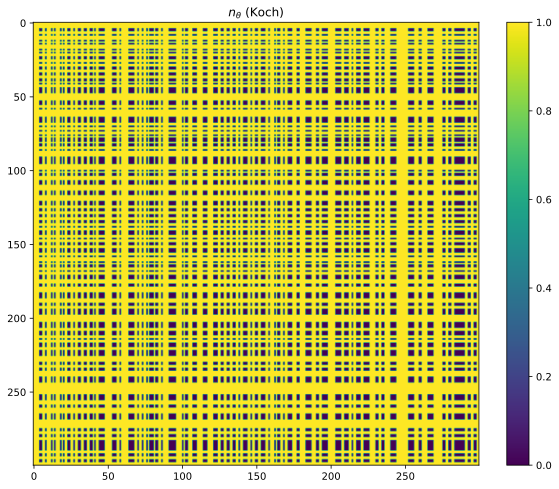

In [ ]:
matrix = np.zeros((truc, truc))
matrix[hspace_charge, :] = 1  # 设置指定行
matrix[:, hspace_charge] = 1  # 设置指定列

fig, ax = plt.subplots(figsize=(10, 8))
plt.imshow(matrix, cmap='viridis', aspect='auto')
plt.title(r'$n_\theta$ (Koch)')
plt.colorbar()
plt.show()


In [ ]:
thresh = 0.0001
hspace_charge = [0, 2]
for s in hspace_charge:
    for i in range(truc):
        if np.abs(drive_term[s, i]/(2*np.pi)) > thresh and i not in hspace_charge:
            hspace_charge.append(i)
hspace_charge.sort()
print('drive_phi=', drive_phi, '; drive_theta = ', drive_theta)
print('nphi threshold=', thresh)
print('num of truncation =', len(hspace_charge))
print('hilbert_space :')
dim = 10
data = hspace_charge
for i in range(0, len(data), dim):
    print(', '.join(map(str, np.round(data[i:i+dim], 8) )), ',')


drive_phi= False ; drive_theta =  True
nphi threshold= 0.0001
num of truncation = 29
hilbert_space :
0, 1, 2, 4, 5, 7, 8, 11, 12, 16 ,
17, 18, 21, 23, 25, 27, 30, 31, 32, 33 ,
37, 38, 40, 41, 42, 45, 46, 47, 48 ,


### drive $n_\theta$ - get fidelity for 100 levels

In [ ]:
tg, drive_amp_A, drive_amp_B, detune_A, detune_B = [22, 0.21142888, 0.04991373, 0.002936, -0.00242995]
truc1=50
hilbert_space = np.arange(truc1)
arg = [drive_amp_A, drive_amp_B, detune_A, detune_B]
args = (H0, drive_term, tg, w_trans_1, w_trans_2, hilbert_space)
f_300 = ut.xgate_fidelity_optimize(arg, *args)
f_300

-1.1384548235470549

### drive $n_\theta$ - get fidelity by removing a level (parallel)

1. truc=50    lg(1-F)=-1.6015
2. truc=100 lg(1-F)=-1.2961

In [ ]:
args = (H0, drive_term, tg, w_trans_1, w_trans_2, hspace_charge)
f_157 = ut.xgate_fidelity_optimize(arg, *args)
f_157

-1.138542318012815

In [ ]:
hspace = np.arange(truc1)
args = [H0, drive_term, w_trans_1, w_trans_2, hspace]
f_theta = Parallel(n_jobs=len(param_theta), verbose=1)(delayed(ut.xgate_fidelity_arg5)(arg, args)
                                            for arg in para_tot)

print('\nfidelity = ')
dim = 5
data = f_theta
for i in range(0, len(data), dim):
    print(', '.join(map(str, np.round(data[i:i+dim], 6) )), ',')

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   2 out of  16 | elapsed:  1.1min remaining:  8.0min



fidelity = 
-1.291915, -0.912229, -1.662145, -1.478222, -1.175574 ,
-1.569847, -0.7981, -2.113408, -1.426514, -2.26666 ,
-2.140774, -0.872873, -2.582661, -2.208428, -2.356036 ,
-2.694133 ,


[Parallel(n_jobs=16)]: Done  16 out of  16 | elapsed:  3.8min finished


In [ ]:
=

In [ ]:
level_start = np.arange(0, truc1, step=1)
levels = np.arange(3, truc1, step=1)
hspace_grid = []
for level in levels:
    hspace_grid.append(np.delete(level_start, level))

f_theta = Parallel(n_jobs=len(levels), verbose=1)(delayed(ut.get_fidelity_given_hspace)(hspace, argz)
                                            for hspace in hspace_grid)
# print('\nfidelity = ')
# dim = 5
# data = f_theta
# for i in range(0, len(data), dim):
#     print(', '.join(map(str, np.round(data[i:i+dim], 6) )), ',')

####  drive $n_\theta$ - get fidelity given levels

In [ ]:
=

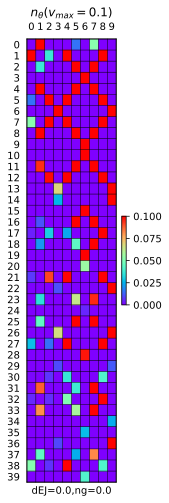

In [ ]:
fig, ax = plt.subplots(figsize=(2,8))
# font_size = 15
truc_x = 10
plt.imshow(np.abs(n_theta[:,:truc_x]), vmax=vmax, aspect="auto",cmap='rainbow')
plt.title(r'$n_{\theta}(v_{max}=$'+f'{vmax})' )
plt.xlabel('dEJ='+f'{dEJ}' + ',ng='+f'{ng}' )
ax.set_xticks(np.arange(0, truc_x, 1), np.arange(0, truc_x, 1))
ax.set_yticks(np.arange(0, truc, 1), np.arange(0, truc, 1))
ax.xaxis.tick_top()
ax.set_xticks(np.arange(-.5, truc_x, 1), minor=True)
ax.set_yticks(np.arange(-.5, truc, 1), minor=True)
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
ax.tick_params(which='both', left=False, top=False)
plt.colorbar(shrink=0.2)
# plt.savefig('image/n_theta.png',dpi=150, bbox_inches='tight')

In [ ]:
# tg_vec = [50]
# argss = (w_trans_1, w_trans_2, states, H_qbt_drive)
# zpX.fidelity_de(tg_vec, argss)

#### all possible transitions for truc1=300

In [ ]:
w_trans = []
trans = []
n_trans = []
for i, state_i in enumerate(hspace_indirect):
    for state_j in hspace_indirect[i:]:
        j = hspace_indirect.index(state_j)
        # print(state_i, state_j)
        if np.abs(drive_term[i, j]/(2*np.pi)) > thresh:
            w_trans.append(np.abs(eval0[state_i] - eval0[state_j]))
            transition = str(state_i) + '-' + str(state_j)
            trans.append(transition)
            n_trans.append(np.abs(drive_term[i, j]/(2*np.pi)))
# for i, _ in enumerate(trans):
#     print(trans[i], w_trans[i])

sort_idx = np.argsort(w_trans)
w_trans = np.sort(np.round(w_trans, 3))
n_trans = [np.round(n_trans[i],3) for i in sort_idx]
trans = [trans[i] for i in sort_idx]

for i, _ in enumerate(trans):
    print(i, trans[i], w_trans[i], n_trans[i])

0 283-284 0.0 1.91
1 131-132 0.0 6.301
2 289-290 0.0 6.537
3 221-222 0.001 1.474
4 150-151 0.003 4.879
5 231-232 0.005 5.143
6 251-252 0.007 7.272
7 106-107 0.009 2.163
8 195-196 0.01 1.463
9 87-88 0.028 3.884
10 133-134 0.044 6.171
11 236-237 0.046 2.607
12 97-98 0.051 0.269
13 207-208 0.055 0.537
14 297-298 0.063 0.734
15 64-65 0.067 1.51
16 186-187 0.069 6.246
17 278-281 0.075 3.052
18 225-226 0.08 3.977
19 270-271 0.093 0.84
20 263-264 0.096 4.941
21 218-220 0.104 1.328
22 30-31 0.177 1.625
23 188-191 0.278 5.153
24 188-192 0.278 0.557
25 121-122 0.338 5.171
26 210-213 0.663 5.771
27 247-248 0.695 6.59
28 72-74 0.72 1.296
29 31-32 0.74 3.249
30 298-299 0.892 4.509
31 102-107 0.896 0.1
32 120-121 0.912 0.868
33 45-47 0.914 1.899
34 46-48 1.05 1.341
35 258-259 1.065 4.474
36 271-274 1.072 7.268
37 230-232 1.19 0.67
38 127-128 1.216 2.411
39 59-62 1.296 3.279
40 156-157 1.382 3.267
41 292-296 1.446 2.523
42 285-288 1.459 7.082
43 155-158 1.462 2.629
44 171-175 1.481 0.95
45 63-64 1.56